# HeI transitions

2025.02.03  k.i.    start  
2025.03.02  k.i.    TermClass, MultipletClass, line profile

In [2]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

%load_ext autoreload
%autoreload 2
import sys

sys.path.append("C:/home/Python/")
from lib.idl_wrapper import iplot
from spectra.spectra_src import Constants as Cst

sys.path.append("../")

import matplotlib.pyplot as plt   # module for plotting
from matplotlib.colors import LogNorm
plt.style.use("ggplot")

import numpy as np                # module for vectorized numeric calculation

from IPython.display import Math
#init_printing()   # hungup
import warnings
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', DeprecationWarning)

from spectra_src.ImportAll import *
from spectra_src.Util.HelpUtil import help_
from spectra_src import Constants as Cst

#-----  enlarge width of cells  -----------------
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>")) 
np.get_printoptions()
np.set_printoptions(linewidth=100)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Ortho He 5-terms model  (multi-term atom)
Asensio Ramos, Trujillo Bueno and Landi Degle Innocenti, 2008

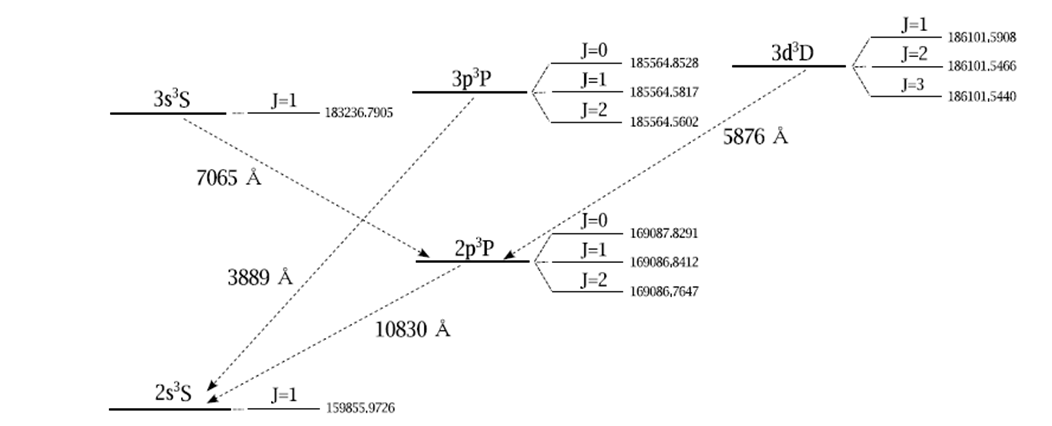


Term ごとのsubstates

$$
\begin{array}{ccc|cc|cc}
\hline
\rm{term}  &  L & S & J & M & & \rm{＃ \ of \ substates} \\
\hline
3d^3D & 2 & 1 & 1 & -1,0,1 & 3 \\
      &   &   & 2 &  -2,-1,0,1,2 & 5 & 15\\
      &   &   & 3 &  -3,-2,-1,0,1,2,3 & 7 \\
\hline
3p^3P & 1 & 1 & 0 & 0 & 1 \\
      &   &   & 1 & -1,0,1 & 3  & 9 \\
      &   &   & 2 & -2,-1,0,1,2 & 5 \\
\hline
3s^3S & 0 & 1 & 1 & -1,0,1 & 3 & 3\\
\hline
2p^3P & 1 & 1 & 0 & 0  & 1 \\
      &   &   & 1 & -1,0,1 & 3 & 9 \\
      &   &   & 2 & -2,-1,0,1,2 & 5\\
\hline
2s^3S & 0 & 1 & 1 & -1,0,1 & 3 & 3\\
\hline
\end{array}
$$

### 異なるterm間の干渉はないとする。density matrix は各term ごとに1つ

L-S term のsubstate 数 $ =  (2L+1)(2S+1)$

density matrix の element 数 $= (2L+1)^2(2S+1)^2 \qquad$

Hermite（複素反対称）であるが、非対角成分が複素数なので独立自由度の数はこれと同じ  



In [3]:
import sympy.physics
import sympy.physics.wigner
import sympy as sp

#---  return L,S,JJ,energy[erg] of a term of ortho He 
def HeI_term_levels(term):
    
    terms = {   # wavenumber of levels J=0,1,2,,, from ATL 2008
        '2s3S': [159855.9726],
        '3s3S': [183236.7905],
        '2p3P': [169087.8291, 169086.8412, 169086.7647],
        '3p3P': [185564.8528, 185564.5817, 185564.5602],
        '3d3D': [186101.5908, 186101.5466, 186101.5440]
    }
    Lc = {'S': 0, 'P': 1, 'D': 2, 'F': 3}
    k2erg = Cst.h_*Cst.c_
    S = (sp.Integer(term[-2])-1)/2
    L = Lc[term[-1]]
    nJ = L+S - sp.Abs(L-S) +1
    JJ = [sp.Abs(L-S)+i for i in sp.Range(nJ)]
    ks = np.array(terms[term],dtype=object)  # np.float64 だと丸めが生じる
    erg = np.array(ks*k2erg,dtype=np.float64)
    
    return(L,S,JJ,erg)
    
upper = '2p3P' ;  Lu,Su,JJu, erg_u = HeI_term_levels(upper)
lower = '2s3S' ;  Ll,Sl,JJl, erg_l = HeI_term_levels(lower)

np.set_printoptions(precision=2,linewidth=100)
print(upper,'  L=',Lu, '  S=',Su,'  J=',JJu)
print(lower,'  L=',Ll, '  S=',Sl,'  J=',JJl)
wl = Cst.c_/((erg_u - erg_l)/Cst.h_)*1e8
print('wl=', wl,'A')


2p3P   L= 1   S= 1   J= [0, 1, 2]
2s3S   L= 0   S= 1   J= [1]
wl= [10832.06 10833.22 10833.31] A


In [4]:
#  return J & M arrays from L-S coupling
def coupled_JMarr(L,S):
    
    nJ = L+S - sp.Abs(L-S) +1
    JJ = [sp.Abs(L-S)+i for i in sp.Range(nJ)]
    Js = []
    Ms = []
    for J in JJ:
        Js += [J]*(2*J+1)
        Ms += [-J+i for i in sp.Range(2*J+1)]
    Js = np.array(Js)
    Ms = np.array(Ms)

    return(Js,Ms)

Js, Ms = coupled_JMarr(1,2)
print(len(Js),type(Js))
print('J = ',Js)
print('M = ',Ms)
#display(sp.Array([Js,Ms]))


15 <class 'numpy.ndarray'>
J =  [1 1 1 2 2 2 2 2 3 3 3 3 3 3 3]
M =  [-1 0 1 -2 -1 0 1 2 -3 -2 -1 0 1 2 3]


==========================================================================================
#  Energy states in Zeeman / Paschen-Back effect
from Kawate talk 2022.12

### HeI 10830 upper state:   $L=1, S=1   \to  1s2p \quad ^3P_{0,1,2}$

$H = H_0 + H_B,   \qquad   H_B =-\bf{\mu}\cdot \bf{B}, \qquad 
\bf{\mu} = \it{\mu_B} ( \it{g_L} \bf{L} + \it{g_S} \bf{S} )$ ：　磁気モーメント

$H_0$ の固有ケット $=\mid JM\rangle  \qquad H_0 \mid(JM)_i\rangle = E_i \mid(JM)_i\rangle$

$H_B$の固有ケット $=\mid LSM_LM_S\rangle  \qquad H_B \mid LSM_LM_S\rangle = -\mu_B B(g_L M_L+g_S M_S)\mid LSM_LM_S\rangle ,\qquad
g_L=1,\quad g_S=2.002319$

$\langle (JM)_i\mid H_0+H_B \mid (JM)_j)\rangle
= E_i \delta_{ij} - \mu_B B \langle (JM)_i\mid g_LL_z + g_SS_z \mid (JM)_j)\rangle,  \qquad  L_z,  S_z :  operator$

$H_{B,ij}= \langle (JM)_i\mid H_B \mid (JM)_j)\rangle = -\mu_B B v_{ij}$

$v_{ij} = \langle (JM)_i\mid g_LL_z + g_SS_z \mid (JM)_j)\rangle 
= \sum_{M_L,M_S}\langle(JM)_i\mid LSM_LM_S\rangle \langle LSM_LM_S\mid(JM)_j\rangle (g_LM_L+g_sM_S)$

### $D = C^{-1} H C, \qquad   D=$ diagonal matrix,      $ \quad C[:,i] = i$-th eigen vector of $H$


In [5]:
# genelate a term class 
from sympy.physics.wigner import clebsch_gordan

class TermClass:
    
    def __init__(self, term, order='J'):
        self.term = term 
        L,S,JJ, erg = HeI_term_levels(term)   # JJ[nJ], erg[nJ]
        self.L = L
        self.S = S
        Js, Ms = coupled_JMarr(L,S)
        self.order = 'J'
        self.Js = Js
        self.Ms = Ms
        #print('L,S,J=',L,S,Js)
        g_L = 1. ; g_S = 2.002319
        Es = np.array(erg/Cst.eV2erg_, dtype=np.float64)
        EIP = 24.58739  # ionization energy from 1S0 of He in eV

        nn = len(Js)
        E0 = np.zeros(nn)
        H0 = np.zeros([nn,nn])  # Hermiltonian in |LM> base
        v = np.zeros([nn,nn])
        #H0 = sp.zeros(nn,nn)  # Hermiltonian in |LM> base
        #v = sp.zeros(nn,nn)

        for i in range(nn):
            Ji = Js[i]
            Mi = Ms[i]
            E0[i] = Es[Ji-Js[0]] - EIP    #  energy relative from continuum in [eV] 
            H0[i,i] = E0[i]    # 
            for j in range(nn):
                Jj = Js[j]
                Mj = Ms[j]
                vij = 0.
                for ML in range(-L,L+1):
                    for MS in range(-S,S+1):
                        vij += clebsch_gordan(L,S,Ji,ML,MS,Mi)*clebsch_gordan(L,S,Jj,ML,MS,Mj)*(g_L*ML+g_S*MS)
                        v[i,j] = vij
        self.E0 = E0
        self.H0 = H0
        self.v = v
        
        if order == 'M':
            self.JMorder('M')

            
    def JMorder(self, order):  # change order of arrays 
        if order == 'M':
            jj = np.argsort(self.Ms).astype(int)
        elif order == 'J':
            jj = np.argsort(self.Js).astype(int)

        self.order = order
        self.Js = self.Js[jj]
        self.Ms = self.Ms[jj]
        self.E0 = self.E0[jj]
        nn = len(self.Js)
        Hm = np.zeros([nn,nn])   #  sorted P
        vm = np.zeros([nn,nn])   #  sorted P
        for i in range(nn):
            for j in range(nn):
                Hm[i,j] = self.H0[jj[i],jj[j]]
                vm[i,j] = self.v[jj[i],jj[j]]
        self.H0 = Hm
        self.v = vm
        print('|JM > ordered in ',self.order)
        
        return(self.order)
                
                
tu = TermClass('2p3P') #,order='M')
tl = TermClass('2s3S')
help_(tu)
print('Ju = ',tu.Js,'   Mu = ',tu.Ms)
tu.JMorder('M')
print('Ju = ',tu.Js,'   Mu = ',tu.Ms)

------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
TermClass
|- term                    str                                  v: 2p3P
|- L                       int                                  v: 1
|- S                       symExpr                              v: 1
|- order                   str                                  v: J
|- Js                      ndarray                              s: (9,)
|- Ms                      ndarray                              s: (9,)
|- E0                      ndarray                              s: (9,)
|- H0                      ndarray                              s: (9, 9)
|- v                       ndarray                              s: (9, 9)
Ju =  [0 1 1 1 2 2 2 2 2]    Mu =  [0 -1 0 1 -2 -1 0 1 2]
|JM > ordered in  M
Ju =  [

In [6]:
term = '2s3S'
term = '3p3P'
t = TermClass(term, order='J')

print('term = '+term+'  L =',t.L,'  S =',t.S)
help_(t)
JM = [t.Js,t.Ms]
display('J/M:',sp.Array(JM))
np.set_printoptions(precision=6,linewidth=100)
print('H0 =')
print(t.H0)# .evalf(5))
np.set_printoptions(precision=3,linewidth=100)
print('v =')
print(t.v)# .evalf(3)) # 数値に変換、精度5桁

term = 3p3P  L = 1   S = 1
------------------------------------------------------------------------------------------
name                       type                                 value/len/shape
------------------------------------------------------------------------------------------
TermClass
|- term                    str                                  v: 3p3P
|- L                       int                                  v: 1
|- S                       symExpr                              v: 1
|- order                   str                                  v: J
|- Js                      ndarray                              s: (9,)
|- Ms                      ndarray                              s: (9,)
|- E0                      ndarray                              s: (9,)
|- H0                      ndarray                              s: (9, 9)
|- v                       ndarray                              s: (9, 9)


'J/M:'

[[0, 1, 1, 1, 2, 2, 2, 2, 2], [0, -1, 0, 1, -2, -1, 0, 1, 2]]

H0 =
[[-1.580285  0.        0.        0.        0.        0.        0.        0.        0.      ]
 [ 0.       -1.580318  0.        0.        0.        0.        0.        0.        0.      ]
 [ 0.        0.       -1.580318  0.        0.        0.        0.        0.        0.      ]
 [ 0.        0.        0.       -1.580318  0.        0.        0.        0.        0.      ]
 [ 0.        0.        0.        0.       -1.580321  0.        0.        0.        0.      ]
 [ 0.        0.        0.        0.        0.       -1.580321  0.        0.        0.      ]
 [ 0.        0.        0.        0.        0.        0.       -1.580321  0.        0.      ]
 [ 0.        0.        0.        0.        0.        0.        0.       -1.580321  0.      ]
 [ 0.        0.        0.        0.        0.        0.        0.        0.       -1.580321]]
v =
[[ 0.     0.    -0.818  0.     0.     0.     0.     0.     0.   ]
 [ 0.    -1.501  0.     0.     0.    -0.501  0.     0.     0.   ]
 [-0.818  0.     0.  

In [7]:
# eigen values & states of perturbed Hermiltonian = H0 + HB, P in order of J in weak B

def HeI_eigenstates(t,B):

    muB = 9.27402e-21  # Borh magneton,  [esu cm]  (esu =√dyn cm, Gauss =√dyn/cm -> muB*Gauss= [erg])
    eV2erg = Cst.eV2erg_  # 1.60217662 * 1.E-12
    g_L = 1. ; g_S = 2.002319

    #Js, Ms, H0, v = HeI_H0_and_v(term)

    H = t.H0 - muB*B*t.v/eV2erg    # in eV
        # H0,v,H は sympy.Matrix, H.shape -> (9,9)
        #disp7lay('H=',H.evalf(6))
    Hn = np.array(H).astype(np.float64)
    #Hn = np.array(H).astype(object)

    E0, C0 = np.linalg.eigh(Hn)     # eigen value & eigen vector mat.
    nn = len(E0)
    E1 = np.zeros(nn)
    C1 = np.zeros([nn,nn])
    #P1 = sp.zeros(nn,nn)

    imx = np.zeros(nn,dtype=int)
    for j in range(nn):   #  sort by max P0[:,j]
        imx[j] = np.argmax(np.abs(C0[:,j]))
    j2 = np.argsort(imx)
    for j in range(nn):  
        E1[j] = E0[j2[j]]
        C1[:,j] = C0[:,j2[j]]

    return(E1,C1)


term = '2p3P'
#term = '2s3S'
B = 6795. # G を超えると計算こける　 固有ベクトルが1つゼロになる  B=10000G はOk
B = 500

t = TermClass(term,order='M')

E1,C1 = HeI_eigenstates(t,B)
Js = t.Js ;  Ms = t.Ms
nn = len(Js)
#np.set_printoptions(precision=3,linewidth=140, formatter={'all': lambda x: f"{x:.5e}"})
np.set_printoptions(precision=5,suppress=True,linewidth=140)

#display('H=',H.evalf(6))
print('B =',B,'G')
print('Eigen values of H [eV]')
print('E1=',E1)
JM = [Js,Ms]
display(sp.Array(JM))
print('Eigen vectors in column C^j_J ordered by '+t.order+' (in weak B)')
print(C1)
print('sum(C[:,j]^2) =',np.sum(C1**2,axis=1))

|JM > ordered in  M
B = 500 G
Eigen values of H [eV]
E1= [-3.6233  -3.62329 -3.6233  -3.62317 -3.6233  -3.62331 -3.6233  -3.62331 -3.62332]


[[2, 1, 2, 0, 1, 2, 1, 2, 2], [-2, -1, -1, 0, 0, 0, 1, 1, 2]]

Eigen vectors in column C^j_J ordered by M (in weak B)
[[ 1.      -0.       0.       0.      -0.       0.      -0.       0.       0.     ]
 [ 0.      -0.98901 -0.14786  0.      -0.       0.      -0.       0.       0.     ]
 [ 0.      -0.14786  0.98901  0.      -0.       0.      -0.       0.       0.     ]
 [ 0.      -0.       0.       0.99981  0.01909  0.00304 -0.       0.       0.     ]
 [ 0.      -0.       0.       0.01933 -0.98532 -0.16962 -0.       0.       0.     ]
 [ 0.      -0.       0.       0.00025 -0.16965  0.9855  -0.       0.       0.     ]
 [ 0.      -0.       0.       0.      -0.       0.      -0.98901 -0.14786  0.     ]
 [ 0.      -0.       0.       0.      -0.       0.      -0.14786  0.98901  0.     ]
 [ 0.      -0.       0.       0.      -0.       0.      -0.       0.       1.     ]]
sum(C[:,j]^2) = [1. 1. 1. 1. 1. 1. 1. 1. 1.]


####  $H$ のeigen state は元の$M$が同じで 異なる$J$ のeigen state が混ざったものとなる（$P$ は$M$ についてblock diagonal）. 新しい eigen state を $ \mid LSjM \rangle$ と表記する     
### $ \quad \mid (LSjM)_j \rangle = \sum_J C^j_J \mid LSJM \rangle$

|JM > ordered in  M


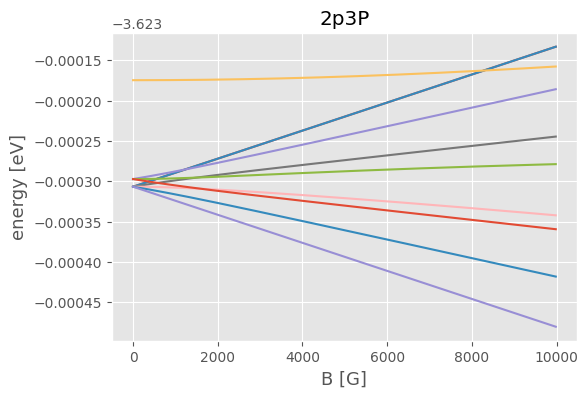

In [8]:
# eigen values (energy of new states) and eigen states on B[:]
def HeI_eigenstate_arr(t,Bs):

    muB = 9.27402e-21  # Borh magneton,  [esu cm]  (esu =√dyn cm, Gauss =√dyn/cm -> muB*Gauss= [erg])
    eV2erg = Cst.eV2erg_  # 1.60217662 * 1.E-12

    nn = len(t.Js)
    nB = len(Bs)
    Es = np.zeros([nn,nB])
    Cs = np.zeros([nn,nn,nB])
    E1 = np.zeros(nn)
    C1 = np.zeros([nn,nn])
    det = np.zeros(nB)

    imx = np.zeros(nn,dtype=int)
    dd = np.zeros(nn)
    Cb = np.identity(nn)
    for k in range(nB):
        B = Bs[k]
        H = t.H0 - muB *B *t.v/eV2erg    # in eV
        # H0,v,H は sympy.Matrix, H.shape -> (9,9)
        #display('H=',H.evalf(6))
        Hn = np.array(H).astype(np.float64)
        det[k] = np.linalg.det(Hn)   # determinant
        E0, C0 = np.linalg.eigh(Hn)     # eigen value & eigen vector mat.
        for j in range(nn):  # order eigen vectors for smooth connection across the crossover
            for j2 in range(nn):
                dd[j2] = np.abs(np.dot(Cb[:,j],C0[:,j2]))
            imn = np.argmax(dd)
            C1[:,j] = C0[:,imn]
            E1[j] = E0[imn]
        Es[:,k] = E1
        Cs[:,:,k] = C1
        Cb = C1

    return(Es,Cs)
    

    
# plot eigen values (energy of new states)
term = '2p3P'
#term = '2s3S'
#term = '3d3D'
Bmax = 10000.  ; nB = 500
dB = Bmax/nB
Bs = np.arange(nB)*dB  # Gauss

t = TermClass(term, order='M')
Es, Cs = HeI_eigenstate_arr(t,Bs)
nn = len(Es)

ax = iplot(Bs,Es[0,:],xtitle='B [G]',ytitle='energy [eV]',title=term)
for i in range(nn):
    ax.plot(Bs,Es[i,:])

## line (component) strength

### Einstein $A_{ul} = \frac{64\pi^4 \nu_{ul}^3}{3c^3 h}\langle u_u \mid \bf{d_{ul}} \mid u_l \rangle^2 \quad  \cdots $ HM2014 (5.104)

### $A_{q (=\Delta M)} \varpropto S^{j_l M_l j_u M_u}_q \varpropto |\langle L_l S_l j_l M_l \mid r_q \mid L_u S_u j_u M_u \rangle |^2 \cdots $ 　dipole 放射、$S_l=S_u$となる

#### $\qquad =\langle L_l S_l j_l M_l \mid r_q \mid L_u S_u j_u M_u \rangle \langle L_u S_u j_u M_u \mid r_q \mid L_l S_l j_l M_l \rangle \quad \cdots (u-l) 対称の形にする$

### $ \mid (LSjM)_j \rangle = \sum_J C^j_J \mid LSJM \rangle  \qquad \cdots $  upper, lower 各term で   

### $\langle L_l S_l j_l M_l \mid r_q \mid L_u S_u j_u M_u \rangle = \sum_{J_l,J_u} C^{j_l}_{J_l} C^{j_u}_{J_u} \langle L_l S_l J_l M_l \mid r_q \mid L_u S_u J_u M_u \rangle$

#### Wigber-Eckart:   
$\langle L_l S_l J_l M_l \mid r_q \mid L_u S_u J_u M_u \rangle = (-1)^{J_u+M_l+1} \sqrt{2J_l+1} \begin{pmatrix} J_l & J_u & 1 \\ -M_l & M_u & q \end{pmatrix} \langle L_l S_l J_l \mid \mid r \mid \mid L_u S_u J_u\rangle$
 $\langle L_u S_u J_u M_u  \mid r_q \mid L_l S_l J_l M_l \rangle = (-1)^{J_l+M_u+1} \sqrt{2J_u+1} \begin{pmatrix} J_u & J_l & 1 \\ -M_u & M_l & q \end{pmatrix} \langle L_u S_u J_u \mid \mid r \mid \mid L_l S_l J_l\rangle$
#### $\qquad \sqrt{2J_l+1} \langle L_l S_l J_l \mid \mid r \mid \mid L_u S_u J_u\rangle^* = (-1)^{J_l-J_u+(0 or 1)} \sqrt{2J_u+1} \langle L_u S_u J_u \mid \mid r \mid \mid L_l S_l J_l\rangle $

#### $r$ は$L$のみに作用する。Landi 2004 (2.108)より、
#### $\langle L_l S_l J_l \mid \mid r \mid \mid L_u S_u J_u\rangle = (-1)^{L_l+S+J_l+1} \sqrt{(2J_u+1)(2L_l+1)} \begin{Bmatrix} L_l & L_u & 1 \\ J_u & J_l & S \end{Bmatrix} \langle L_l \mid \mid r \mid \mid L_u \rangle \delta_{S_lS_u}$

#### $ \sum_{j_l M_l j_u M_u} S^{j_l M_l j_u M_u}_q = 1$ を課すと、（Landi 2004 (3.64)）

#### $\qquad \langle L_l S_l J_l \mid \mid r \mid \mid L_u S_u J_u\rangle \rightarrow (-1)^{L_l+S+J_l+1}  \sqrt{\frac{3}{2S+1} (2J_u+1)} \begin{Bmatrix} L_l & L_u & 1 \\ J_u & J_l & S \end{Bmatrix} $
#### $\qquad \langle L_u S_u J_u \mid \mid r \mid \mid L_l S_l J_l\rangle \rightarrow (-1)^{L_u+S+J_u+1}  \sqrt{\frac{3}{2S+1} (2J_l+1)} \begin{Bmatrix} L_u & L_l & 1 \\ J_l & J_u & S \end{Bmatrix} \quad とすればよい$


In [8]:
# for test,   eather <lower|r|upper> and <upper|r|lower> can be used

from sympy.physics.wigner import wigner_3j, wigner_6j

Lu=2 ; Ju=2 ; Mu=1 ; Ll=1 ; Jl=1; Ml=0  ; S=1
rme1 = sp.sqrt(3./(2*S+1) *(2*Ju+1)) * wigner_6j(Ll, Lu, 1, Ju, Jl, S) # reduced matrix element
a1 = sp.sqrt(2*Jl+1) * wigner_3j(Ju, Jl, 1, -Mu, Ml, Mu-Ml) * rme1
rme2 = sp.sqrt(3./(2*S+1) *(2*Jl+1)) * wigner_6j(Lu, Ll, 1, Jl, Ju, S) # reduced matrix element
a2 = sp.sqrt(2*Ju+1) * wigner_3j(Jl, Ju, 1, -Ml, Mu, Ml-Mu) * rme2
print(sp.N(a1),sp.N(a2))
wigner_6j(Lu, Ll, 1, Jl, Ju, S),wigner_6j(Ll, Lu, 1, Ju, Jl, S)
wigner_6j(Ll, Lu, 1, Ju, Jl, S),wigner_6j(Lu, Ll, 1, Jl, Ju, S)

0.273861278752583 0.273861278752583


(-sqrt(5)/10, -sqrt(5)/10)

In [40]:
class MultipletClass:

    def __init__(self,uterm,lterm,Bs,order='J'):

        #--- cleate terms and unperturbed transition ---
        self.name = ''
        tu = TermClass(uterm,order=order)
        tl = TermClass(lterm,order=order)
        self.tu = tu
        self.tl = tl
        nu = len(tu.Js)
        nl = len(tl.Js)
        ifact = 3.   # normalization factor for intens to make blue comp. of 10830 as 1

        dMmat = np.zeros([nl,nu],dtype=int)
        for j in range(nl):
            dMmat [j,:] = tu.Ms - tl.Ms[j]
        ij = np.where(np.abs(dMmat) <= 1)
        dM = dMmat[ij]
        nt = len(dM)
        print('# of transitions: ',nt)
        self.Ju0 = tu.Js[ij[1]]
        self.Mu = tu.Ms[ij[1]]
        self.Jl0 = tl.Js[ij[0]]
        self.Ml = tl.Ms[ij[0]]

        wfct = Cst.c_*Cst.h_/Cst.eV2erg_*1e8    # factor for eV --> A
        w0mat = np.zeros([nl,nu],dtype=np.float64)  # wavelength in A
        JJmat = np.zeros([nl,nu],dtype=np.float64)  # connection between u-l sublebels in eigen J-state
        wmat = np.zeros([nl,nu],dtype=np.float64)  # wavelength in A
        jjmat = np.zeros([nl,nu],dtype=np.float64)  # connection between u-l sublebels in perturbed j-states
        # < LSJM(l) || rq || LSJM(u) >  -->  rq[il,iu]
        S = tu.S   # = tl.S
        for j in range(nl):
            Ll = tl.L ;  Jl = tl.Js[j] ;  Ml = tl.Ms[j]
            for i in range(nu):
                w0mat[j,i] = wfct/(tu.E0[i] - tl.E0[j])
                Lu = tu.L ;  Ju = tu.Js[i] ;  Mu = tu.Ms[i]
                rme1 = sp.sqrt(3./(2*S+1) *(2*Ju+1)) * wigner_6j(Ll, Lu, 1, Ju, Jl, S) # reduced matrix element
                JJmat[j,i] = sp.sqrt(2*Jl+1) * wigner_3j(Ju, Jl, 1, -Mu, Ml, Mu-Ml) * rme1

        self.w0 = w0mat[ij]
        S0 = JJmat**2
        self.S0 = S0[ij]*ifact  
        
        #--- incomplete Paschen-Back ---
        nB = len(Bs)
        Eus, Cus = HeI_eigenstate_arr(tu,Bs)    # E[nu], P[nu,nB]
        Els, Cls = HeI_eigenstate_arr(tl,Bs)
        self.Bs = Bs
        self.Eus = Eus
        self.Els = Els

        wl = np.zeros([nt,nB],dtype=np.float64)  # wavelength in A
        S = np.zeros([nt,nB],dtype=np.float64)  # relative intensity
        for k in range(nB):
            B = Bs[k]
            #print(k,B)
            Eu = Eus[:,k] ; Cu = Cus[:,:,k] ; El = Els[:,k] ; Cl = Cls[:,:,k]
            for jp in range(nl):      # perturbed levels
                for ip in range(nu):
                    wmat[jp,ip] = wfct/(Eu[ip] - El[jp])
                    cpl = 0.
                    for j in range(nl):  #J-j couplings
                        for i in range(nu):
                            cpl += Cu[i,ip]*Cl[j,jp]*JJmat[j,i]
                    jjmat[jp,ip] = cpl

            S1 = jjmat**2
            wl[:,k] = wmat[ij]
            S[:,k] = S1[ij]*ifact

        self.wl = wl
        self.S = S

    #---------------------------------------------------------------------------
    def plot_wshift(self):  #-- plot B vs wl
        cols = ['black','red','blue']
        wl00 = np.average(self.w0)
        wl = self.wl
        S = self.S
        dM = self.Mu-self.Ml
        Bs = self.Bs
        nt = len(dM)
        nB = len(Bs)
        ax = iplot(wl[0,:]-wl00,Bs,ytitle='B [G]',xtitle='wl [A] from '+f'{wl00:7.2f}A',nodata=1 )
        for k in range(nt):
            #ax.plot(wl[k,:]-wl00,Bs, color=cols[dM[k]])
            for i in range(nB-1):
                alp = np.min([S[k,i],1])
                ax.plot(wl[k,i:i+2]-wl00, Bs[i:i+2], color=cols[dM[k]], alpha=alp)

    #---------------------------------------------------------------------------
    def plot_strength(self,color='dM'):  #-- plot intens vs B        
        cols = ['black','red','blue']
        ax = iplot(self.Bs,self.S[0,:],xtitle='B [G]')
        dM = self.Mu-self.Ml
        for k in range(len(dM)):
            if color == 'dM':
                col = cols[dM[k]]
            elif color == 'Ju':
                col = cols[self.Ju0[k] % 3]
            ax.plot(self.Bs,self.S[k,:], color=col, linewidth=0.5)

    #---------------------------------------------------------------------------
    def plot_state_energy(self,term='upper',Bmax=None):
        if term == 'upper':
            E0 = self.tu.E0
            Es = self.Eus
        else:
            E0 = self.tl.E0
            Es = self.Els
        
        E00 = np.average(E0)
        Bs = self.Bs
        if Bmax != None:
            ii = np.where(Bs < Bmax)
            Bs = Bs[ii]
            Es = Es[:,ii]
        n = len(E0)
        nB = len(Bs)
        ax = iplot(Bs,Es[0,:].reshape(nB) -E00,xtitle='B [G]',ytitle=f'$\Delta E$ [eV]',nodata=1)
        for i in range(n):
            ax.plot(Bs,Es[i,:].reshape(nB) -E00, linewidth=0.7)
        if Bmax != None:
            ax.set_xlim([0,Bmax])

            
    #---------------------------------------------------------------------------
    def plot_transitions(self,iB=15, wrange=[-1.5,0.7], figsize=(10,7), _font=20, rate=10, _cmap='rainbow', fig=None,  ax=None):
        #iB=15; _figsize=[10,7]; _font=20; rate=10; _cmap='rainbow'; fig=None;  ax=None

        if ax == None:
            fig, ax =plt.subplots(figsize=figsize)

        yrange = [0,1]
        yuc = 0.3   # y for center of upper level energy 
        ylc = 0.1   # y for center of lowerlevel energy 
        y0 = 0.75   # y for component
        E2y = 2000  # y-scale for energy eV
        i2y = 0.17   # y-scale for intensity

        ax.grid(False)
        #ax.xaxis.set_visible(False)
        ax.yaxis.set_visible(False)
        ax.set_xlim(wrange)
        ax.set_ylim(yrange)

        ww = wrange[1]-wrange[0]
        xx = [wrange[0]+0.05*ww,wrange[1]-0.05*ww]
        bb = np.array([1,1])

        ax.set_title('B='+f'{self.Bs[iB]:5.0f}G' )

        cols = ['blue','black','red','green']
        nu = len(self.tu.E0)     
        E00 = np.average(self.tu.E0)
        yus = yuc + (self.Eus[:,iB]-E00)*E2y
        for i in range(nu):
            ax.plot(xx,yus[i]*bb,color=cols[self.tu.Js[i]],linewidth=0.3)
        nl = len(self.tl.E0)
        E00 = np.average(self.tl.E0)
        yls = ylc + (self.Els[:,iB]-E00)*E2y
        for i in range(nl):
            ax.plot(xx,yls[i]*bb,color='black',linewidth=0.3)

        wl00 = np.average(self.w0)
        ax.set_xlabel('dwl [A] from '+f'{wl00:7.2f}A')
        ax.plot(xx,y0*bb,color='black',linewidth=0.5)
        nt = len(self.w0)      # # of transition = 19 for 10830A
        dM = self.Mu - self.Ml
        dws = self.wl[:,iB] - wl00
        for i in range(nt):
            Ju01 = self.Ju0[i]  ;   Mu1 = self.Mu[i]
            idxu = np.where((Ju01 == self.tu.Js) & (Mu1 == self.tu.Ms))[0][0]
            Jl01 = self.Jl0[i]  ;   Ml1 = self.Ml[i]
            idxl = np.where((Jl01 == self.tl.Js) & (Ml1 == self.tl.Ms))[0][0]
            ax.plot(dws[i]*bb,[yls[idxl],yus[idxu]], color=cols[Ju01])
            dy = self.S[i,iB]*i2y
            if dM[i] != 0:
                dy = -dy
            ax.plot(dws[i]*bb, [y0,y0+dy], color=cols[Ju01])

        
            
#-----------------------------------------------------------------------------
#name = 'HeI 7065A'    ; uterm = '3s3S' ;  lterm = '2p3P'  ; dwrange = [-1., 1.]
#name = 'HeI 3889A'    ; uterm = '3p3P' ;  lterm = '2s3S'  ; dwrange = [-1., 1.]
name = 'HeI D3 5876A' ; uterm = '3d3D' ;  lterm = '2p3P'  ; dwrange = [-1., 1.]
name = 'HeI 10830A'   ; uterm = '2p3P' ;  lterm = '2s3S'  ; dwrange = [-2.5, 2.]

Bmax = 1000.  ; nB = 100 ;   dB = Bmax/nB
Bs = np.arange(nB)*dB  # Gauss

m = MultipletClass(uterm,lterm,Bs)
m.name = name
#help_(c)
print('Ju = ',m.tu.Js)
print('Ju0=',m.Ju0)
print('Mu =',m.Mu)
print('Jl0=',m.Jl0)
print('Ml =',m.Ml)
#-- line intensity --
Jus = [0,1,2]
lint = np.zeros(3)
for i in range(3):
    ii = np.where(m.Ju0 == Jus[i])[0]
    lint[i] = np.sum(m.S0[ii])
print('line strength: ',lint)
#help_(m)


# of transitions:  19
Ju =  [0 1 1 1 2 2 2 2 2]
Ju0= [0 1 1 2 2 2 0 1 1 1 2 2 2 0 1 1 2 2 2]
Mu = [0 -1 0 -2 -1 0 0 -1 0 1 -1 0 1 0 0 1 0 1 2]
Jl0= [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Ml = [-1 -1 -1 -1 -1 -1 0 0 0 0 0 0 0 1 1 1 1 1 1]
line strength:  [1. 3. 5.]


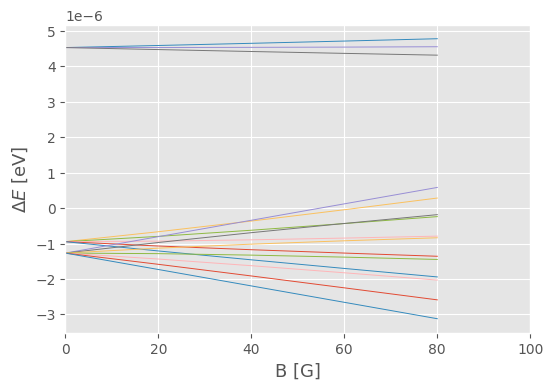

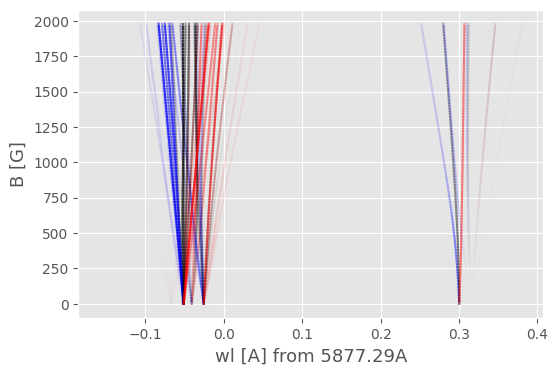

In [296]:

#m.plot_transitions(iB=10,wrange=dwrange)
m.plot_state_energy(term='upper',Bmax=100)
#help_(m)
m.plot_wshift()

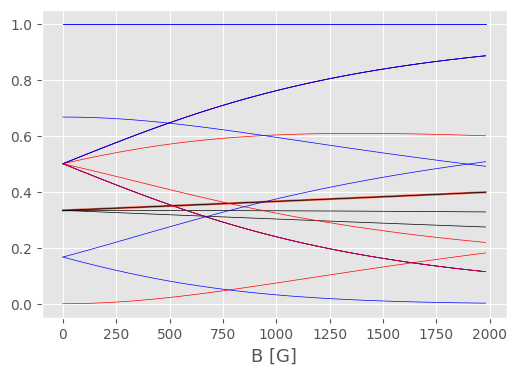

In [263]:
m.plot_strength(color='Ju')
#m.plot_state_energy()


# Line profiles  

10830.pptx  

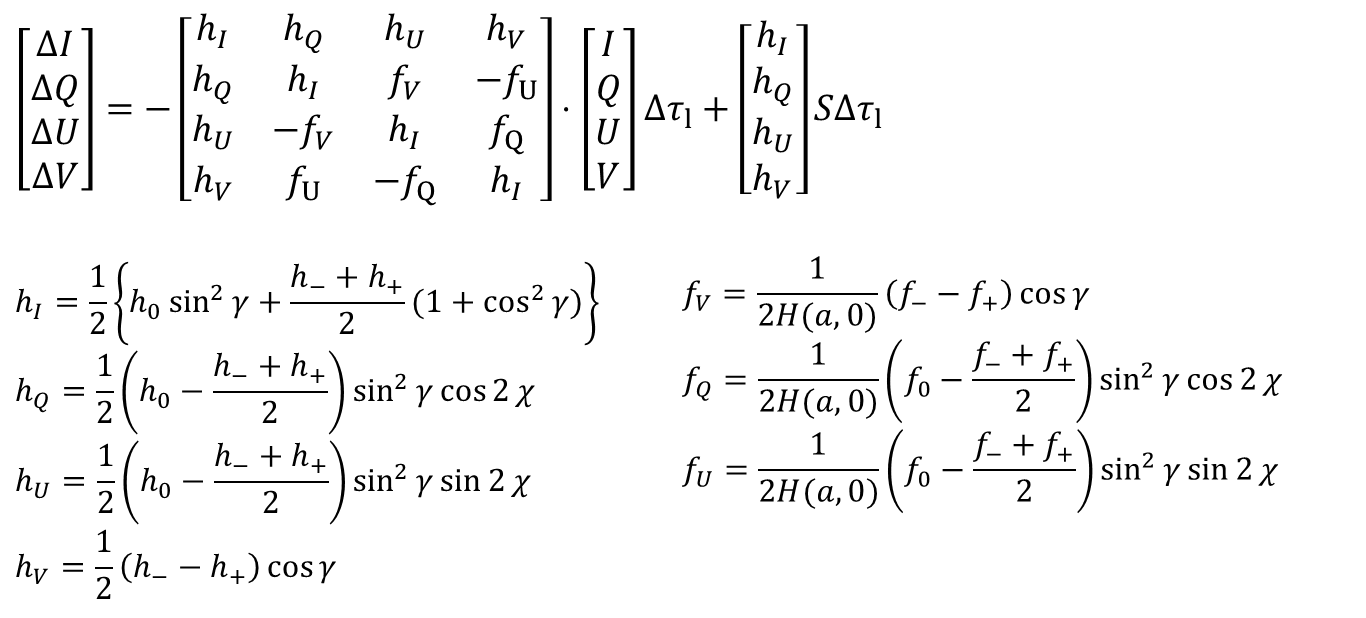

hf keys :  dict_keys(['hsm', 'hp', 'hsp', 'fsm', 'fp', 'fsp'])
B=   30G, $\gamma$=  0$\degree$, $\chi$=  0$\degree$,  $\Delta\lambda_D$= 2.0km/s (  962 K))


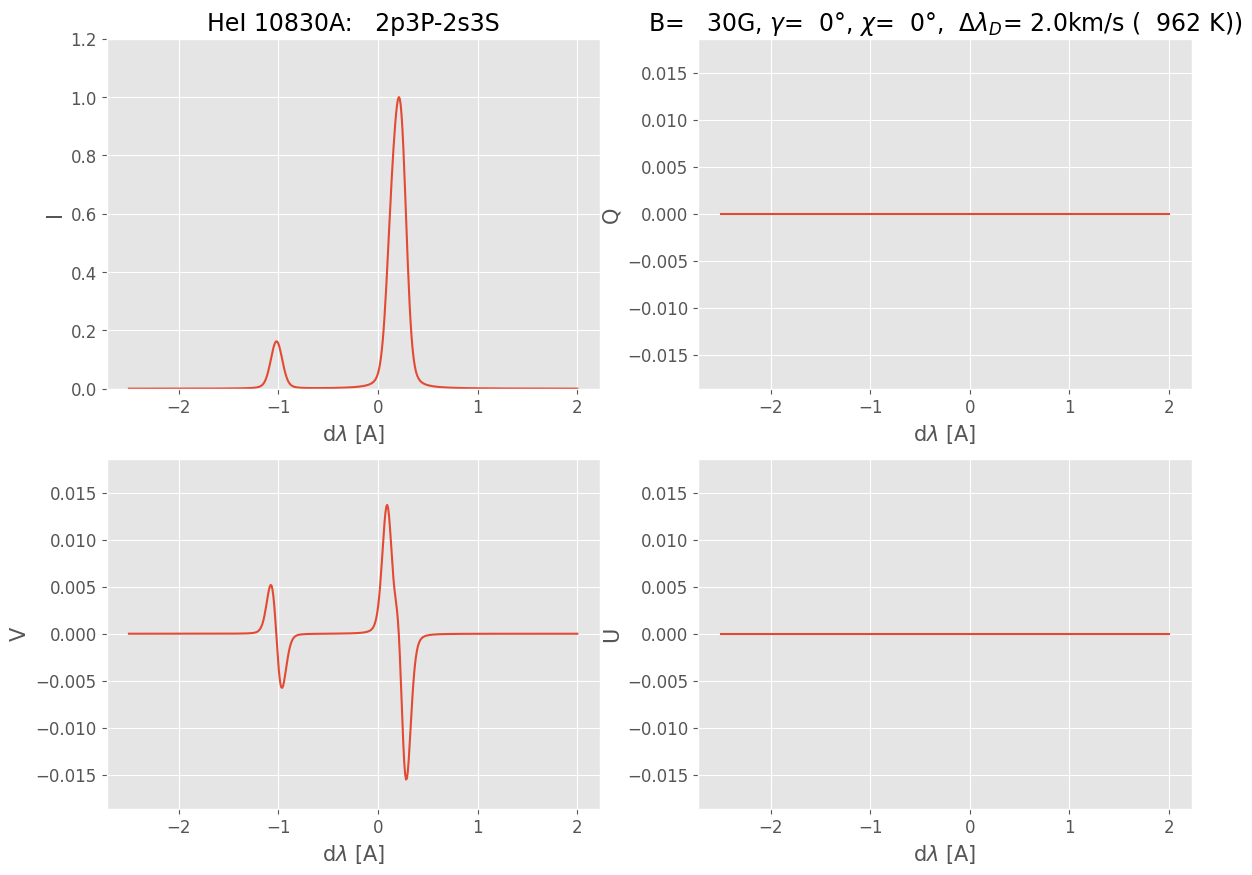

In [45]:
#  calculate k-matrix

from spectra.spectra_src.RadiativeTransfer import Profile as pf
#********************************************************************************
def hfprof(m, iB, wl00, dwl, dopw=0.1, a=0.2): 

    v = dwl/dopw ; dv = v[1]-v[0]

    hp = hsp = hsm = fp = fsp = fsm = np.zeros(nw, dtype='float')
    ip = isp = ism = 0.

    dM = m.Mu - m.Ml
    nt = len(dM)
    for i in range(0,nt):
        #print(cg2[il[i],iu[i]],dd[il[i],iu[i]],dM[il[i],iu[i]])
        dw1 = m.wl[i,iB] - wl00
        dM1 = dM[i]
        S1 = m.S[i,iB]
        h1, f1 = pf.hf_(a,v-dw1/dopw)
        if dM1 == 0:
            hp = hp + S1*h1
            fp = fp + S1*f1
            ip = ip + S1
        if dM1 == -1:
            hsm = hsm + S1*h1
            fsm = fsm + S1*f1
            ism = ism + S1
        if dM1 == 1:
            hsp = hsp + S1*h1
            fsp = fsp + S1*f1
            isp = isp + S1
    hh,_ = pf.hf_(a,v)
    h0 = np.max(hh)
    #hp=hp/ip/h0 ;  hsm=hsm/ism/h0  ;  hsp=hsp/isp/h0
    #fp=fp/ip/h0 ;  fsm=fsm/ism/h0  ;  fsp=fsp/isp/h0
    hf = {
        'hsm': hsm,  # sigma comp. dM = -1
        'hp' : hp,   # pi comp.    dM = 0
        'hsp': hsp,  # sigma comp. dM = +1
        'fsm': fsm,
        'fp' : fp,
        'fsp': fsp
    }
    return(hf)

#***********************************************************************
def getkmat(hf, gam, xai):
# gam :  inclination (B-LOS angle), deg.
# xai :  azimuth, deg.
    
    hp = hf['hp'] ;    hsm = hf['hsm'] ;    hsp = hf['hsp']
    fp = hf['fp'] ;    fsm = hf['fsm'] ;    fsp = hf['fsp']
    
    gamr = gam*np.pi/180.
    xair = xai*np.pi/180.
    sg = np.sin(gamr)
    cg = np.cos(gamr)
    s2x = np.sin(2.*xair)
    c2x = np.cos(2.*xair)
    sg2=sg**2
    hi = hp/2.*sg2 + (hsm+hsp)/4.*(1.+cg**2)
    hq = (hp/2.-(hsm+hsp)/4.) * sg2 * c2x
    hu = (hp/2.-(hsm+hsp)/4.) * sg2 * s2x
    hv = (hsm-hsp)/2.*cg
    fr = (fsm-fsp)/2.*cg
    fw = (fp/2.-(fsm+fsp)/4.) * sg2

    kmat = np.array( \
            [[hi,  hq,     hu,    hv    ], \
            [hq,   hi,     fr,  -fw*s2x ], \
            [hu,  -fr,     hi,   fw*c2x ], \
            [hv, fw*s2x,-fw*c2x,   hi   ]] \
            )

    return(kmat)

#***************************************************
def plot_kmat(dwl,kmat,pmax=1):
    
    fig, axs = plt.subplots(4,4, figsize=(14,10))
    for i in np.arange(0,4):
        for j in np.arange(0,4):
            axs[i,j].plot(dwl,kmat[i,j,:])
            axs[i,j].set_ylim(-pmax,pmax)

    plt.show()

#***************************************************
def plot1(ax,dwl,prof,ylabel='',ylim=None):

    ax.plot(dwl,prof)
    ax.set_xlabel('d$\lambda$ [A]', fontsize=15)
    ax.set_ylabel(ylabel, fontsize=15)
    if ylim != None:
        ax.set_ylim(ylim)
    ax.tick_params(labelsize =12)

def plot_iquv(dwl, S_out, title1='', title2='', pmax=None):
    
    if pmax == None:
        pmax = np.max(np.abs(S_out[[1,2,3],:]))*1.2
    fig, axs = plt.subplots(2,2, figsize=(14,10))
    plot1(axs[0,0],dwl,S_out[0,:],ylabel='I',ylim=[0,1.2])
    plot1(axs[0,1],dwl,S_out[1,:],ylabel='Q',ylim=[-pmax,pmax])
    plot1(axs[1,1],dwl,S_out[2,:],ylabel='U',ylim=[-pmax,pmax])
    plot1(axs[1,0],dwl,S_out[3,:],ylabel='V',ylim=[-pmax,pmax])
    axs[0,0].set_title(title1, fontsize=17)
    axs[0,1].set_title(title2, fontsize=17)
    
#************************************************************

iB = 3
#  B:     field strength, G
dopv = 2   #  Doppler width in dopw, km/s
a = 0.2      #  damping width, A
gam = 0.     #  inclination (B-LOS angle), deg.
xai = 0.     #  azimuth, deg.
# dwl[:] : d-wavelength range, A
wl00 = np.average(m.w0)
dwmin = dwrange[0] ; dwmax = dwrange[1] ;  nw = 501     # in A
dwl = np.linspace(dwmin,dwmax,nw)
dopw = dopv/Cst.c_*1e5*wl00

hf = hfprof(m, iB, wl00, dwl, dopw=dopw)
print('hf keys : ',hf.keys())    
kmat = getkmat(hf,gam,xai)
#plot_kmat(dwl,kmat)
S_out = kmat[:,0,:]
S_out = S_out/np.max(S_out[0,:])

B = m.Bs[iB]

mHe = Cst.mH_*4
T = (dopv*1e5)**2 *mHe /2/Cst.k_
title1 = m.name+':   '+m.tu.term+'-'+m.tl.term
title2 = f"B={B:5.0f}G, "+"$\gamma$"+f"={gam:3.0f}$\degree$, "+"$\chi$"+f"={xai:3.0f}$\degree$,  " \
    +"$\Delta\lambda_D$"+f"={dopv:4.1f}km/s "+f"({T:5.0f} K))"

plot_iquv(dwl,S_out,title1=title1,title2=title2) #,pmax=pmax)
print(title2)



In [43]:
dopv

2

In [29]:
Cst.c_

29979246000.0

obsolate

##  --------------------------------------------------------------




In [28]:
## transition; prepare term class and E(B), P(B)

w0 = 10830.   ; uterm = '2p3P' ;  lterm = '2s3S'
Bmax = 2000.  ; nB = 100 ;   dB = Bmax/nB
Bs = np.arange(nB)*dB  # Gauss

tu = TermClass(uterm, order='M')
tl = TermClass(lterm, order='M')
#help_(tu)
#help_(tl)
Eus, Cus = HeI_eigenstate_arr(tu,Bs)    # E[nu], P[nu,nB]
Els, Cls = HeI_eigenstate_arr(tl,Bs)
nu = len(tu.Js)
nl = len(tl.Js)

np.set_printoptions(precision=6,suppress=True)
print('E0u =',tu.E0)
print('E0l =',tl.E0)
print('shape of Eu & Cu ',Eus.shape,Cus.shape)
print('shape of El & Cl ',Els.shape,Cls.shape)
print('C[:,J]**2 = ',np.sum(Cus[:,:,90]**2,axis=0))


|JM > ordered in  M
|JM > ordered in  M
E0u = [-3.623307 -3.623297 -3.623307 -3.623175 -3.623297 -3.623307 -3.623297 -3.623307 -3.623307]
E0l = [-4.767779 -4.767779 -4.767779]
shape of Eu & Cu  (9, 100) (9, 9, 100)
shape of El & Cl  (3, 100) (3, 3, 100)
C[:,J]**2 =  [1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [51]:
from sympy.physics.wigner import wigner_3j, wigner_6j

w0mat = np.zeros([nl,nu],dtype=np.float64)  # wavelength in A
JJmat = np.zeros([nl,nu],dtype=np.float64)  # connection between u-l sublebels in eigen J-state
wmat = np.zeros([nl,nu],dtype=np.float64)  # wavelength in A
jjmat = np.zeros([nl,nu],dtype=np.float64)  # connection between u-l sublebels in perturbed j-states

wfct = Cst.c_*Cst.h_/Cst.eV2erg_*1e8    # factor for eV --> A

dMmat = np.zeros([nl,nu],dtype=int)
for j in range(nl):
    dMmat [j,:] = tu.Ms - tl.Ms[j]
display('dM = ',dMmat)
ij = np.where(np.abs(dMmat) <= 1)
dM = dMmat[ij]
nt = len(dM)
print('# of transitions: ',nt)

# < LSJM(l) || rq || LSJM(u) >  -->  rq[il,iu]
S = tu.S   # = tl.S
for j in range(nl):
    Ll = tl.L ;  Jl = tl.Js[j] ;  Ml = tl.Ms[j]
    for i in range(nu):
        w0mat[j,i] = wfct/(tu.E0[i] - tl.E0[j])
        Lu = tu.L ;  Ju = tu.Js[i] ;  Mu = tu.Ms[i]
        rme1 = sp.sqrt(3./(2*S+1) *(2*Ju+1)) * wigner_6j(Ll, Lu, 1, Ju, Jl, S) # reduced matrix element
        JJmat[j,i] = sp.sqrt(2*Jl+1) * wigner_3j(Ju, Jl, 1, -Mu, Ml, Mu-Ml) * rme1

w0 = w0mat[ij]
int0 = JJmat**2
int0 = int0[ij]
np.set_printoptions(precision=4,suppress=True)
display([[tl.Ms],[tu.Ms]])
display('JJmat:',JJmat)
np.set_printoptions(precision=2,suppress=True)
print('dM =',dM)
print('w0 =',w0)
print('inten =',int0)b
#print([[dM],[w0],[inten]])


'dM = '

array([[-1,  0,  0,  1,  1,  1,  2,  2,  3],
       [-2, -1, -1,  0,  0,  0,  1,  1,  2],
       [-3, -2, -2, -1, -1, -1,  0,  0,  1]])

# of transitions:  19


[[array([-1, 0, 1], dtype=object)],
 [array([-2, -1, -1, 0, 0, 0, 1, 1, 2], dtype=object)]]

'JJmat:'

array([[ 0.5774, -0.4082, -0.4082,  0.3333,  0.4082,  0.2357,  0.    ,  0.    ,  0.    ],
       [ 0.    ,  0.4082, -0.4082, -0.3333,  0.    ,  0.4714, -0.4082, -0.4082,  0.    ],
       [ 0.    ,  0.    ,  0.    ,  0.3333, -0.4082,  0.2357,  0.4082, -0.4082,  0.5774]])

dM = [-1  0  0  1  1  1 -1 -1  0  0  0  1  1 -1 -1 -1  0  0  1]
w0 = [10833.31 10833.22 10833.31 10832.06 10833.22 10833.31 10833.22 10833.31 10832.06 10833.22 10833.31 10833.22 10833.31 10832.06 10833.22
 10833.31 10833.22 10833.31 10833.31]
inten = [0.33 0.17 0.17 0.11 0.17 0.06 0.17 0.17 0.11 0.   0.22 0.17 0.17 0.11 0.17 0.06 0.17 0.17 0.33]
